In [1]:
import nibabel as nib
import numpy as np
import cv2
import os
import torch

In [2]:
nii_file = "abide.cc.bvol.20150121/abide.cc.bvol.20150118/Caltech/0051456/session_1/anat_1/Caltech_0051456_brain_seg.nii.gz"
nii_data = nib.load(nii_file).get_fdata()

In [49]:
output_dir = "outputImage"
os.makedirs(output_dir, exist_ok=True)
for i in range(nii_data.shape[2]):
    slice_image = (nii_data[:, :, i] * 255).astype(np.uint8)
    cv2.imwrite(os.path.join(output_dir, f"slice_{i}.png"), slice_image)

In [50]:
import nibabel as nib
1
# Dosya yolları
cc_file = 'abide.cc.bvol.20150121/abide.cc.bvol.20150118/Caltech/0051456/session_1/anat_1/abide_cc.nii'
msp_file = 'abide.cc.bvol.20150121/abide.cc.bvol.20150118/Caltech/0051456/session_1/anat_1/abide_msp.nii'
seg_file = 'abide.cc.bvol.20150121/abide.cc.bvol.20150118/Caltech/0051456/session_1/anat_1/Caltech_0051456_brain_seg.nii.gz'
cc_img = nib.load(cc_file)
msp_img = nib.load(msp_file)
seg_img = nib.load(seg_file)
# Verileri numpy array olarak aldim
cc_data = cc_img.get_fdata()
msp_data = msp_img.get_fdata()
seg_data = seg_img.get_fdata()

In [51]:
print(cc_data.shape)
print(msp_data.shape)
print(seg_data.shape)

(512, 512, 1)
(512, 512, 1)
(176, 256, 256)


In [52]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import os
output_img_dir = "OUT/IMG"
output_mask_dir = "OUT/MSK"
# Tek dilim verisini kaydet
plt.imsave(f"{output_img_dir}/abide_cc.png", cc_data[:, :, 0], cmap='gray')
plt.imsave(f"{output_mask_dir}/abide_msp.png", msp_data[:, :, 0], cmap='gray')

C:\Users\ibrah\AppData\Local\Temp\ipykernel_18540\3149853363.py:6: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  img = imageio.imread("OUT/IMG/abide_cc.png")
C:\Users\ibrah\AppData\Local\Temp\ipykernel_18540\3149853363.py:7: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  msp = imageio.imread("OUT/MSK/abide_msp.png")


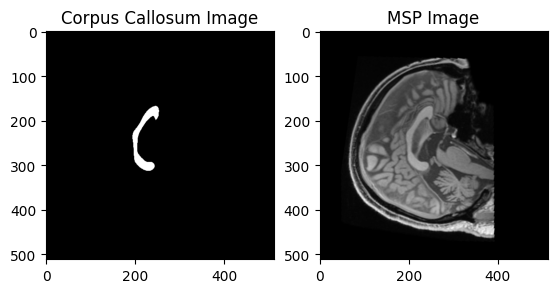

In [53]:
import matplotlib.pyplot as plt
import numpy as np
2
import imageio
#görselleştirme
img = imageio.imread("OUT/IMG/abide_cc.png")
msp = imageio.imread("OUT/MSK/abide_msp.png")
#mask = imageio.imread("OUT/MSK/mask_0.png")
plt.figure(figsize=(10, 10))
plt.subplot(1, 3, 1)
plt.title("Corpus Callosum Image")
plt.imshow(img, cmap='gray')
plt.subplot(1, 3, 2)
plt.title("MSP Image")
plt.imshow(msp, cmap='gray')

In [61]:
import os
import glob
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt

base_dir = "abide.cc.bvol.20150121/abide.cc.bvol.20150118"
output_img_dir = "OUT/IMG"
output_mask_dir = "OUT/MSK"

os.makedirs(output_img_dir, exist_ok=True)
os.makedirs(output_mask_dir, exist_ok=True)

def normalize(img):
    if np.max(img) - np.min(img) == 0:
        return img
    return (img - np.min(img)) / (np.max(img) - np.min(img))

hasta_sayaci = 0


for root, dirs, files in os.walk(base_dir):
    if root.endswith("anat_1"):
        
        img_files = glob.glob(os.path.join(root, "*msp*.nii*"))
        mask_files = glob.glob(os.path.join(root, "*cc*.nii*")) 

        if not img_files or not mask_files:
            continue

        try:
            img_data = nib.load(img_files[0]).get_fdata()
            mask_data = nib.load(mask_files[0]).get_fdata()

            img_slice = img_data[:, :, 0]
            mask_slice = mask_data[:, :, 0]

            img_slice = np.rot90(img_slice)
            mask_slice = np.rot90(mask_slice)

            img_slice = normalize(img_slice)
            mask_binary = (mask_slice > 0).astype(np.uint8)

            if np.sum(mask_binary) == 0:
                continue

            hasta_id = root.split(os.sep)[-3]
            
            img_path = os.path.join(output_img_dir, f"{hasta_id}.png")
            mask_path = os.path.join(output_mask_dir, f"{hasta_id}.png")

            # Resimleri kaydet
            plt.imsave(img_path, img_slice, cmap='gray')
            plt.imsave(mask_path, mask_binary, cmap='gray', vmin=0, vmax=1)
            
            hasta_sayaci += 1

        except Exception as e:
            print(f"Hata ({root.split(os.sep)[-3]}): {e}")

print(f"Hasta / Fotoğraf Sayısı: {hasta_sayaci}")

KeyboardInterrupt: 